# Workshop: Building Gemma 3 from Scratch
## Notebook 4: Rotary Positional Embeddings (RoPE)

**Estimated Time: 15 minutes**

Transformers are permutation-invariant, meaning they don't naturally know the order of tokens. **Rotary Positional Embeddings (RoPE)** encode position by rotating the Query and Key vectors in 2D space. The angle of rotation depends on the position in the sequence.

In **Gemma 3**, RoPE has a crucial twist: **dual frequencies** — 10K for local layers, 1M for global layers.

## Learning Objectives:
1. Understand the intuition: encoding position as rotation.
2. Implement the 2D rotation math.
3. Learn why RoPE allows for better relative position modeling.
4. Implement Gemma 3's **dual-frequency RoPE**.

In [1]:
import torch
import matplotlib.pyplot as plt
import math
import sys

print(f"Python version: {sys.version}")
print(f"PyTorch version: {torch.__version__}")

head_dim = 96  # Gemma 3: 768 / 8 = 96
seq_len = 128  # Enough to see the rotation pattern
rope_theta_local = 10_000.0   # Gemma 3 local layers
rope_theta_global = 1_000_000.0  # Gemma 3 global layers
rope_rescale_factor = 8.0      # For context extension (32K -> 128K)

Python version: 3.12.13 (main, Mar 10 2026, 18:15:41) [Clang 21.1.4 ]
PyTorch version: 2.5.1


## 1. Computing Theta (Frequencies)

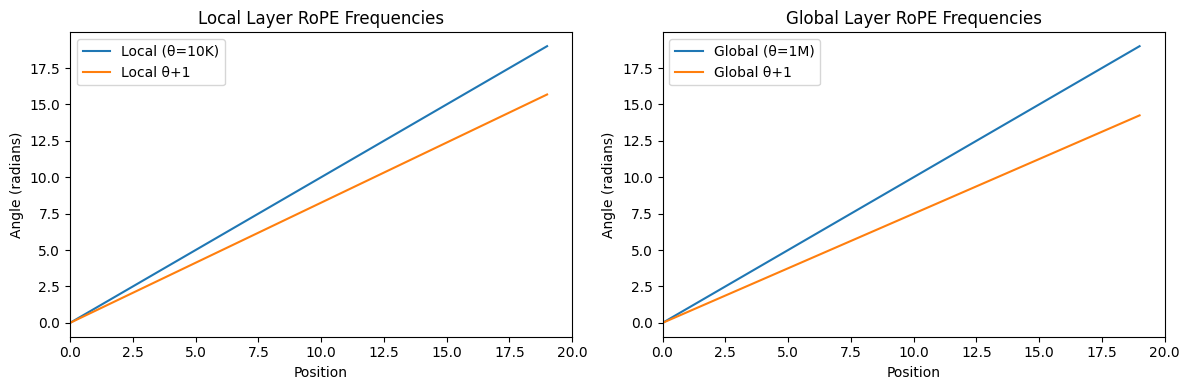

In [2]:
def compute_rope_freqs_rope(head_dim, seq_len, theta_base=10_000.0):
    """Compute RoPE frequencies for a given layer type."""
    # Compute inverse frequencies: 1/theta^(i/d_k)
    inv_freq = 1.0 / (theta_base ** (torch.arange(0, head_dim, 2).float() / head_dim))
    # Compute angles for each position
    t = torch.arange(seq_len)
    freqs = torch.outer(t, inv_freq)  # (seq_len, head_dim/2)
    return freqs

# Local layer RoPE (theta=10K)
freqs_local = compute_rope_freqs_rope(head_dim, seq_len, rope_theta_local)

# Global layer RoPE (theta=1M) - higher theta = slower rotation = longer-range awareness
freqs_global = compute_rope_freqs_rope(head_dim, seq_len, rope_theta_global)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(freqs_local[:20, 0].detach().numpy(), label='Local (θ=10K)')
plt.plot(freqs_local[:20, 1].detach().numpy(), label='Local θ+1')
plt.title('Local Layer RoPE Frequencies')
plt.xlabel('Position')
plt.ylabel('Angle (radians)')
plt.legend()
plt.xlim(0, 20)

plt.subplot(1, 2, 2)
plt.plot(freqs_global[:20, 0].detach().numpy(), label='Global (θ=1M)')
plt.plot(freqs_global[:20, 1].detach().numpy(), label='Global θ+1')
plt.title('Global Layer RoPE Frequencies')
plt.xlabel('Position')
plt.ylabel('Angle (radians)')
plt.legend()
plt.xlim(0, 20)

plt.tight_layout()
plt.show()

## 2. Gemma 3's Dual-Frequency RoPE: Rescaled Global Layers

In Gemma 3, global layers use theta=1M (vs 10K for local). Combined with the rescale factor of 8, this enables the model to handle **128K context**.

$$\theta_{global} = 10^6 \times \text{rescale_factor} = 8 \times 10^6$$

In [3]:
def compute_rope_with_frequency(head_dim, seq_len, theta_base):
    """Compute cos and sin for RoPE with given theta."""
    inv_freq = 1.0 / (theta_base ** (torch.arange(0, head_dim, 2).float() / head_dim))
    t = torch.arange(seq_len)
    freqs = torch.outer(t, inv_freq)
    return torch.cos(freqs), torch.sin(freqs)

# For a given layer, choose the right RoPE frequency
def get_layer_rope_freq(layer_idx):  
    """Return theta for the given layer."""
    if layer_idx % 6 == 5:  # Global layer
        return rope_theta_global * rope_rescale_factor
    return rope_theta_local

## 3. The Rotation Logic

In [4]:
def apply_rope(x, cos, sin):
    """Apply rotary positional embedding."""
    d = x.shape[-1]
    # Split x into two halves
    x_left = x[..., : d // 2]
    x_right = x[..., d // 2 :]
    
    # The rotation formula:
    # x'_1 = x_1 × cos(θ) - x_2 × sin(θ)
    # x'_2 = x_1 × sin(θ) + x_2 × cos(θ)
    # x'_2 = x_1 sin(θ) + x_2 cos(θ)
    x_rotated = torch.cat([-x_right, x_left], dim=-1)
    
    return (x * cos) + (x_rotated * sin)

# Verify with dummy data
x = torch.randn(1, 1, 4, 96)  # (B, H, T, D)
cos, sin = compute_rope_with_frequency(96, 4, 10_000)
# Broadcast cos/sin to match x shape
cos = cos[:x.shape[-2]].unsqueeze(0).unsqueeze(0)  # (1, 1, T, D/2)
sin = sin[:x.shape[-2]].unsqueeze(0).unsqueeze(0)

x_rotated = apply_rope(x, cos, sin)
print(f"Input shape:  {x.shape}")
print(f"Rotated shape: {x_rotated.shape}")
print("✅ RoPE applied successfully!")

RuntimeError: The size of tensor a (96) must match the size of tensor b (48) at non-singleton dimension 3

## 4. Why is this good?

When we compute the dot product between a Query at position $m$ and a Key at position $n$, the rotation ensures the score depends only on the **relative distance** $(m - n)$, not absolute positions. This is the key insight of RoPE.

Gemma 3's dual-frequency design:
- **Local (θ=10K)**: standard rotation for short-range attention
- **Global (θ=8M)**: much slower rotation → finer-grained distance encoding over long sequences

## Exercise:
Visualize how the dot product between two rotated vectors changes as you increase their distance.

In [ ]:
v1 = torch.randn(1, 1, 1, head_dim)
v2 = torch.randn(1, 1, 1, head_dim)

distances = range(32)
dot_products = []

cos_local, sin_local = compute_rope_with_frequency(head_dim, 33, 10_000)

for d in distances:
    x1 = apply_rope(v1, cos_local[:1].unsqueeze(0).unsqueeze(0), sin_local[:1].unsqueeze(0).unsqueeze(0))
    x2 = apply_rope(v2, cos_local[d:d+1].unsqueeze(0).unsqueeze(0), sin_local[d:d+1].unsqueeze(0).unsqueeze(0))
    dot = (x1 * x2).sum().item()
    dot_products.append(dot)

plt.figure(figsize=(10, 4))
plt.plot(list(distances), dot_products)
plt.xlabel("Distance (m - n)")
plt.ylabel("Dot Product")
plt.title("RoPE: How cosine similarity decays with distance")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Key Takeaway

Gemma 3 uses **dual-frequency RoPE**:
- Local layers: θ=10K (same as Gemma 3)
- Global layers: θ=8M (10K × rescale_factor=8 × 10, extended for 128K context)
- Each pair of dimensions is rotated by a different frequency